In [1]:
%load_ext autoreload
%autoreload 2

import cupy as cp
from utils.data_loader import ImagenetteDataLoader
from utils.model import Network

import warnings
warnings.filterwarnings("ignore")

Failed to read module file 'c:\Users\DANIELPEDERZINI\AppData\Local\Programs\Python\Python311\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\DANIELPEDERZINI\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DANIELPEDERZINI\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\DANIELPEDERZINI\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _f

## Loading the Data

In [2]:
train_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="train",
    target_size=(224, 224)
)

x_train, y_train = train_loader.load_images(normalize=True)
x_train.shape, y_train.shape

((9469, 3, 224, 224), (9469, 10))

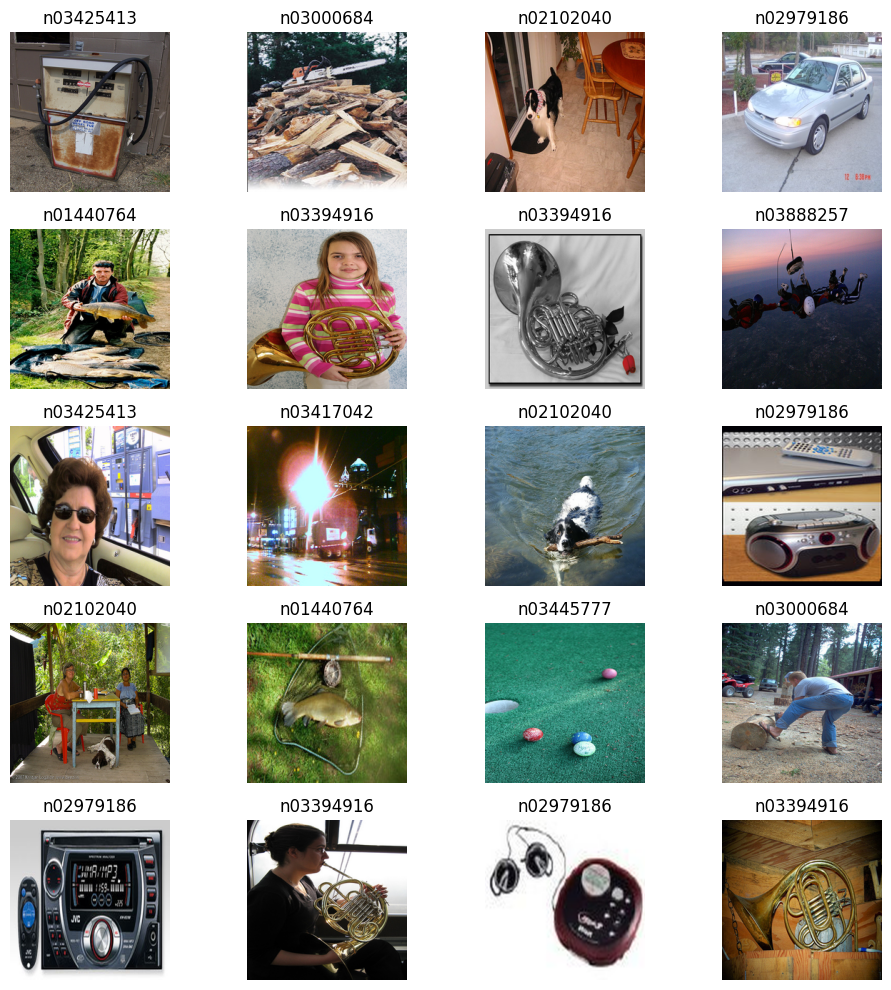

In [3]:
random_indices = cp.random.randint(0, len(x_train), size=20)
train_loader.plot_batch(random_indices.get().tolist(), figsize=(10, 10))

**x_batch** = (N, C, IH, IW)

**filters** = (F, C, KH, KW)

**conv_out** = (N, F, OH, OW)

---

**N** = Batch size

**C** = Channels

**IH, IW** = Image height/width

**F** = Number of filters

**KH, KW** = Kernel height/width

**OH, OW** = Output height/width

**p** = Padding

**s** = Stride

**P** = Patch

---

**H'** = H + 2p

**W'** = W + 2p

**OH** = [(H' - KH) / s] + 1

**OW** = [(W' - KW) / s] + 1

---

**P[c, u, v]** = Xpad[n, c, i + u, j + v]

Where **c** goes from 0 to C - 1

Where **u** goes from 0 to KH - 1

Where **v** goes from 0 to KW - 1

**P** = Xpad[n, :, i:i + KH, j:j + KW]

---

**patch** = (C, KH, KW)

**flattened_patch** = (C * KH * KW)

**num_patches** = (N * OH * OW)

**im2col_matrix** = (C * KH * KW, N * OH * OW)

---

**filter** = (C, KH, KW)

**flattened_filters** = (F, C * KH * KW)

**conv_output** = flattened_filters * im2col_matrix

**conv_output** = F * (N * OH * OW)

**reshaped_output** = (N, F, OH, OW)

In [32]:
num_filters = 5
kernel_height = 3
kernel_width = 3

In [33]:
filters = cp.random.random(size=(num_filters, 3, kernel_height, kernel_width))
filter_columns = cp.prod(cp.array(filters.shape[-3:])).item()
filters_matrix = cp.reshape(filters, newshape=(num_filters, filter_columns))
filters_matrix.shape

(5, 27)

In [ ]:
epochs = 1

In [ ]:
def im2col(x_batch):
    num_samples, num_channels, img_height, img_width = x_batch.shape

In [5]:
def run_filter(filter, x):
    _, f_height, f_width = filter.shape
    _, x_height, x_width = x.shape
    
    out_height = x_height - f_height + 1
    out_width = x_width - f_width + 1
    
    output = cp.zeros(shape=(out_height, out_width))
    
    for i in range(out_height):
        for j in range(out_width):
            output[i, j] = cp.sum(filter * x[:, i:i+f_height, j:j+f_width])
    
    return output

In [6]:
def conv_forward(x):
    filter_outputs = []
    
    for filter in filters:
        filter_outputs.append(run_filter(filter, x))

    return cp.array(filter_outputs)

In [ ]:
output = None

for epoch in range(epochs):
    for i in range(10):
        output = conv_forward(x_train[i])

In [8]:
output[0]

array([[4.72048258, 5.64727092, 6.34962596, ..., 8.93330114, 9.20643057,
        8.86880602],
       [4.43775801, 5.20290508, 6.03886766, ..., 8.80578068, 8.59376993,
        8.26514553],
       [4.68969431, 5.24787104, 5.80237742, ..., 9.05054078, 8.48830454,
        7.93780284],
       ...,
       [2.53417929, 1.96732168, 2.04042327, ..., 3.41522829, 3.77811997,
        4.72973128],
       [2.36508828, 2.17744737, 2.24512888, ..., 2.96460266, 3.29622712,
        4.03749718],
       [2.8489679 , 2.43842388, 2.5340125 , ..., 2.91370212, 2.86392221,
        3.53275612]], shape=(222, 222))

In [9]:
layer_definitions = [
    {"type": "ReLU", "input_size": 300, "num_neurons": 300},
    {"type": "ReLU", "input_size": 300, "num_neurons": 200},
    {"type": "ReLU", "input_size": 200, "num_neurons": 100},
    {"type": "ReLU", "input_size": 100, "num_neurons": 50},
    {"Sigmoid": "ReLU", "input_size": 20, "num_neurons": 1}
]

network = Network(layer_definitions=layer_definitions)

In [10]:
network.describe()

Network Architecture

Layer 1: ReluLayer
  Weights Shape: (300, 300) | Biases Shape: (300,)
  Parameters: 90,300

Layer 2: ReluLayer
  Weights Shape: (300, 200) | Biases Shape: (200,)
  Parameters: 60,200

Layer 3: ReluLayer
  Weights Shape: (200, 100) | Biases Shape: (100,)
  Parameters: 20,100

Layer 4: ReluLayer
  Weights Shape: (100, 50) | Biases Shape: (50,)
  Parameters: 5,050

Layer 5: Layer
  Weights Shape: (20, 1) | Biases Shape: (1,)
  Parameters: 21

Total Parameters: 175,671
